In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("01_data/processed/nhanes_analytic_clean.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: 5,992 rows × 37 columns


In [5]:
# Check which feature columns have missing values
features_check = [
    "age", "poverty_income_ratio", "education",
    "hba1c", "systolic_bp", "diastolic_bp",
    "total_cholesterol", "bmi", "waist_circumference",
    "undiagnosed_diabetes", "undiagnosed_prediabetes",
    "undiagnosed_hypertension", "undiagnosed_hyperlipidemia",
    "composite_risk_score", "has_insurance", "usual_care_site",
    "outpatient_visits", "gender_encoded", "race_encoded", "health_encoded"
]

print("Missing values per feature:")
for col in features_check:
    if col in df.columns:
        missing = df[col].isna().sum()
        print(f"  {col}: {missing}")
    else:
        print(f"  {col}: NOT FOUND IN DATAFRAME")

Missing values per feature:
  age: 0
  poverty_income_ratio: 0
  education: 0
  hba1c: 0
  systolic_bp: 0
  diastolic_bp: 0
  total_cholesterol: 0
  bmi: 0
  waist_circumference: 0
  undiagnosed_diabetes: 0
  undiagnosed_prediabetes: 0
  undiagnosed_hypertension: 0
  undiagnosed_hyperlipidemia: 0
  composite_risk_score: 0
  has_insurance: 9
  usual_care_site: 0
  outpatient_visits: 0
  gender_encoded: 0
  race_encoded: 0
  health_encoded: 5992


In [6]:
# Fix health_encoded — self_rated_health is already numeric (1-5) in CSV
# 1=Excellent, 2=Very Good, 3=Good, 4=Fair, 5=Poor
# Use it directly as numeric — no mapping needed
df["health_encoded"] = pd.to_numeric(df["self_rated_health"], errors="coerce")

# Fix gender encoding
df["gender_encoded"] = df["gender"].map({"Male":0, "Female":1})

# Fix race encoding
df["race_encoded"] = df["race_ethnicity"].map({
    "Non-Hispanic White":0, "Non-Hispanic Black":1,
    "Mexican American":2,   "Other Hispanic":3,
    "Non-Hispanic Asian":4, "Other/Multiracial":5
})

# Fix has_insurance — fill 9 missing with mode
df["has_insurance"] = df["has_insurance"].fillna(df["has_insurance"].mode()[0])

# Verify
print("Missing after fix:")
for col in ["health_encoded", "gender_encoded", "race_encoded", "has_insurance"]:
    print(f"  {col}: {df[col].isna().sum()}")

Missing after fix:
  health_encoded: 0
  gender_encoded: 0
  race_encoded: 0
  has_insurance: 0


In [7]:
# Features going into the model
features = [
    "age", "poverty_income_ratio", "education",
    "hba1c", "systolic_bp", "diastolic_bp",
    "total_cholesterol", "bmi", "waist_circumference",
    "undiagnosed_diabetes", "undiagnosed_prediabetes",
    "undiagnosed_hypertension", "undiagnosed_hyperlipidemia",
    "composite_risk_score",
    "has_insurance", "usual_care_site", "outpatient_visits",
    "gender_encoded", "race_encoded", "health_encoded"
]

# Target variable
target = "er_visit_binary"

# Build X and y
model_df = df[features + [target]].dropna()
X = model_df[features]
y = model_df[target]

print(f"Features:    {len(features)}")
print(f"Sample size: {len(X):,}")
print(f"ER visit rate: {y.mean()*100:.1f}%")
print(f"Class distribution:\n{y.value_counts()}")

Features:    20
Sample size: 5,992
ER visit rate: 19.7%
Class distribution:
er_visit_binary
0    4811
1    1181
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"\nClass distribution before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print(f"Training set size after SMOTE: {X_train_sm.shape[0]:,}")

Training set: 4,793 rows
Test set:     1,199 rows

Class distribution before SMOTE:
er_visit_binary
0    3848
1     945
Name: count, dtype: int64

Class distribution after SMOTE:
er_visit_binary
0    3848
1    3848
Name: count, dtype: int64
Training set size after SMOTE: 7,696


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

# Logistic Regression
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(random_state=42, max_iter=1000))
])
lr_pipeline.fit(X_train_sm, y_train_sm)
print("✅ Logistic Regression trained")

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_sm, y_train_sm)
print("✅ Random Forest trained")

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100, random_state=42,
    eval_metric="logloss", verbosity=0
)
xgb_model.fit(X_train_sm, y_train_sm)
print("✅ XGBoost trained")

print("\n✅ All three models trained successfully")

✅ Logistic Regression trained
✅ Random Forest trained
✅ XGBoost trained

✅ All three models trained successfully


In [10]:
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)

models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest":       rf_model,
    "XGBoost":             xgb_model
}

results = {}
print("=" * 60)
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        "auc":       auc,
        "f1":        report["weighted avg"]["f1-score"],
        "precision": report["weighted avg"]["precision"],
        "recall":    report["weighted avg"]["recall"]
    }

    print(f"\n{name}")
    print(f"  AUC-ROC:   {auc:.3f}")
    print(f"  F1 Score:  {report['weighted avg']['f1-score']:.3f}")
    print(f"  Precision: {report['weighted avg']['precision']:.3f}")
    print(f"  Recall:    {report['weighted avg']['recall']:.3f}")
print("=" * 60)


Logistic Regression
  AUC-ROC:   0.698
  F1 Score:  0.704
  Precision: 0.766
  Recall:    0.675

Random Forest
  AUC-ROC:   0.709
  F1 Score:  0.749
  Precision: 0.739
  Recall:    0.791

XGBoost
  AUC-ROC:   0.647
  F1 Score:  0.730
  Precision: 0.712
  Recall:    0.762


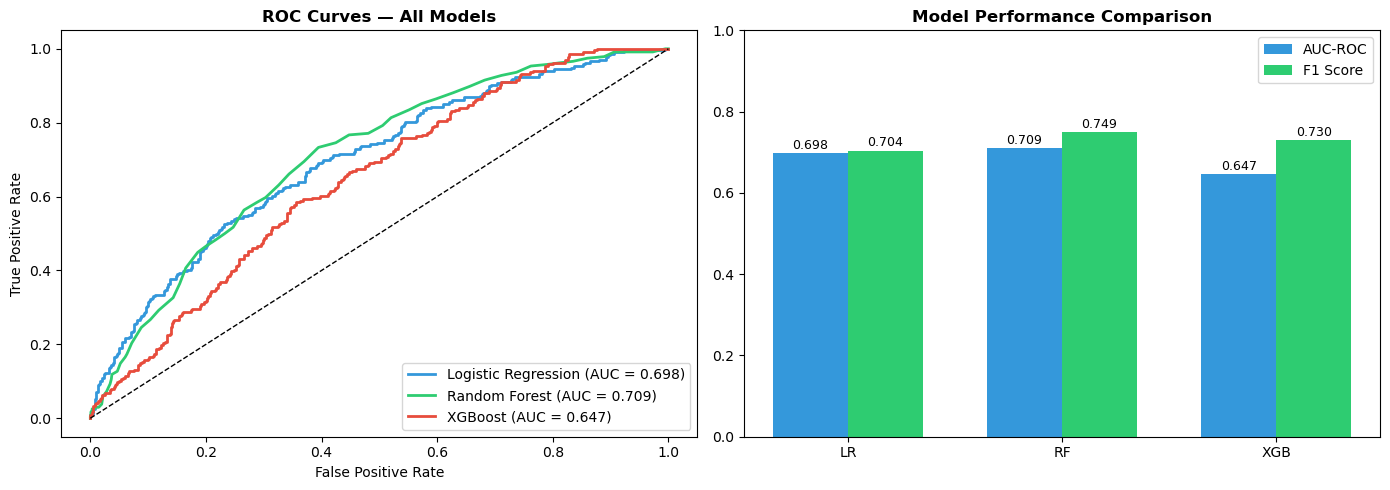

✅ ROC curves saved


In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#3498db", "#2ecc71", "#e74c3c"]
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC = {auc:.3f})")

axes[0].plot([0,1],[0,1],"k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — All Models", fontweight="bold")
axes[0].legend(loc="lower right")

model_names = list(results.keys())
auc_scores  = [results[m]["auc"] for m in model_names]
f1_scores   = [results[m]["f1"]  for m in model_names]

x = np.arange(len(model_names))
width = 0.35
axes[1].bar(x - width/2, auc_scores, width, label="AUC-ROC", color="#3498db")
axes[1].bar(x + width/2, f1_scores,  width, label="F1 Score", color="#2ecc71")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["LR", "RF", "XGB"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Model Performance Comparison", fontweight="bold")
axes[1].legend()
for i, (auc, f1) in enumerate(zip(auc_scores, f1_scores)):
    axes[1].text(i - width/2, auc + 0.01, f"{auc:.3f}", ha="center", fontsize=9)
    axes[1].text(i + width/2, f1  + 0.01, f"{f1:.3f}",  ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("01_data/processed/phase3_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves saved")

SHAP values shape after fix: (1199, 20)


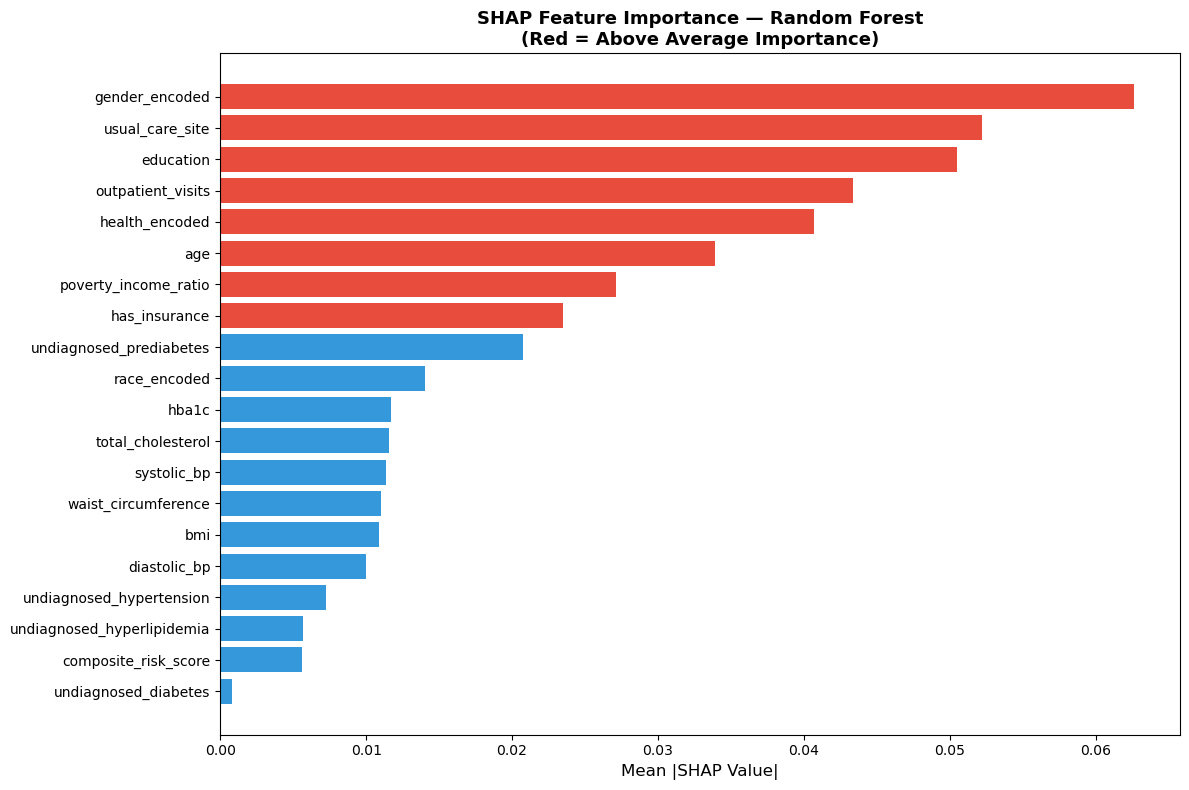

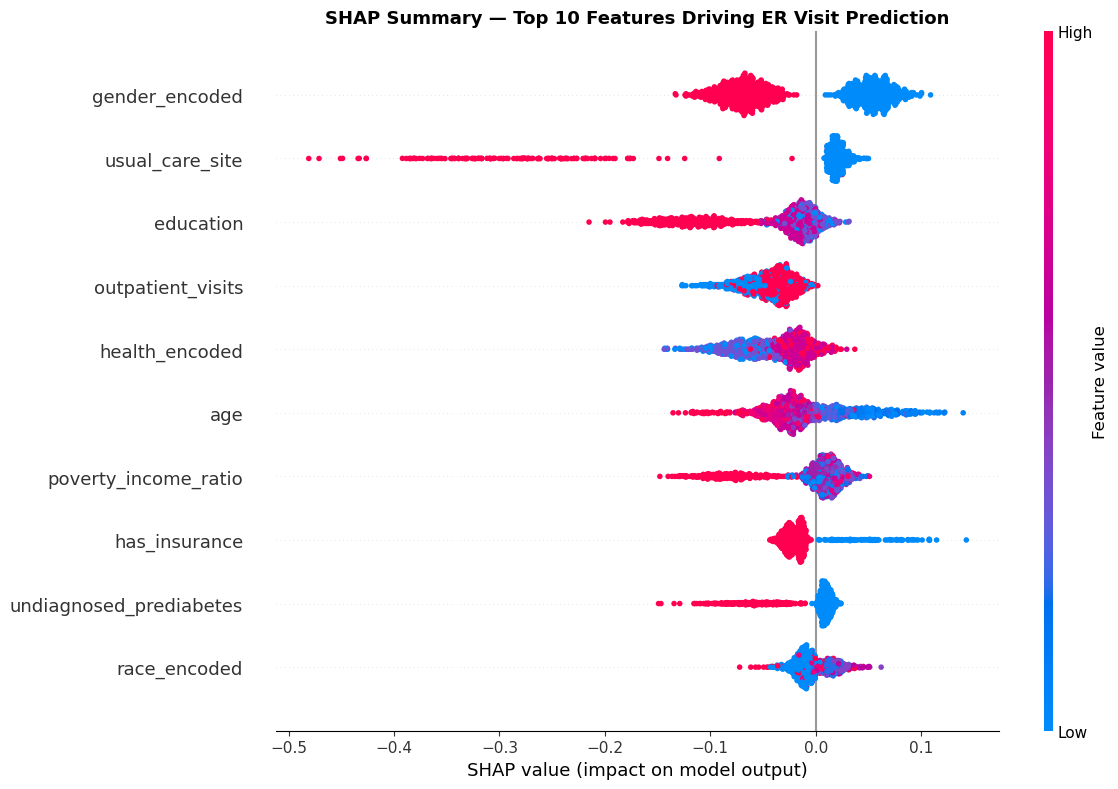

✅ SHAP plots saved

Top 5 most important features:
  1. gender_encoded: 0.0626
  2. usual_care_site: 0.0522
  3. education: 0.0505
  4. outpatient_visits: 0.0434
  5. health_encoded: 0.0407


In [14]:
import shap
import pandas as pd

# Use Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Shape is (1199, 20, 2) — take index [:, :, 1] for positive class
shap_vals = shap_values[:, :, 1]
print(f"SHAP values shape after fix: {shap_vals.shape}")

# Convert to DataFrame
X_test_df = pd.DataFrame(X_test.values, columns=features)

# ── Bar plot — mean absolute SHAP values ──
plt.figure(figsize=(12, 8))
shap_df = pd.DataFrame(shap_vals, columns=features)
mean_shap = shap_df.abs().mean().sort_values(ascending=True)

colors_bar = ["#e74c3c" if x > mean_shap.mean() else "#3498db"
              for x in mean_shap.values]
plt.barh(mean_shap.index, mean_shap.values, color=colors_bar)
plt.xlabel("Mean |SHAP Value|", fontsize=12)
plt.title("SHAP Feature Importance — Random Forest\n(Red = Above Average Importance)",
          fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("01_data/processed/phase3_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Top 10 features dot plot ──
top_features = mean_shap.sort_values(ascending=False).head(10).index.tolist()
top_idx = [features.index(f) for f in top_features]

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_vals[:, top_idx],
    X_test_df[top_features],
    feature_names=top_features,
    show=False,
    plot_size=None
)
plt.title("SHAP Summary — Top 10 Features Driving ER Visit Prediction",
          fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("01_data/processed/phase3_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ SHAP plots saved")
print(f"\nTop 5 most important features:")
for i, (feat, val) in enumerate(mean_shap.sort_values(ascending=False).head(5).items()):
    print(f"  {i+1}. {feat}: {val:.4f}")

In [15]:
# Save final model results summary
results_df = pd.DataFrame(results).T
results_df.to_csv("01_data/processed/phase3_model_results.csv")
print("✅ Model results saved")
print(results_df.round(3))

✅ Model results saved
                       auc     f1  precision  recall
Logistic Regression  0.698  0.704      0.766   0.675
Random Forest        0.709  0.749      0.739   0.791
XGBoost              0.647  0.730      0.712   0.762
